In [55]:
import pandas as pd

import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [56]:
def show_all_rows(df):
    with pd.option_context("display.max_rows", None, 
                       "display.max_columns", None,
                       "display.max_colwidth", None):
        display(df)

# ARS a USD
def transformacion_ars_usd(df):
    f=df["currency"]=="ARS"
    df.loc[f,"price"]=df.loc[f,"price"]/78.5
    df.loc[f,"currency"]="USD"
    return df

# 1EROS Filtros
def primeros_filtros(df_ent ,df_ap):
    df_ent = df_ent.loc[(df_ent["price"].notna()) & (df_ent["currency"] == "USD") & \
    (df_ent["l2"] == "Capital Federal") & (df_ent["operation_type"] == 'Venta') & \
    (df_ent["l3"].isin(df_ap["l3"].unique()))&\
    (df_ent["property_type"].isin(["Cochera", "Departamento", "Casa","PH"]))]

    df_ent=df_ent.drop_duplicates()
    return df_ent

def conversion_ph_to_casa(df):
    f=df["property_type"] =="PH"
    df.loc[f,"ph"] =1
    df.loc[~f,"ph"]=0
    df.loc[f,"property_type"] = "Casa"
    return df


# L3 & L4
def extraccion_l4_text(df):
    subgrupos_to_barrios = {
    # Recoleta
    'Barrio Norte': 'Recoleta',

    # Balvanera
    'Once': 'Balvanera',
    'Abasto': 'Balvanera',

    # Palermo
    'Palermo Hollywood': 'Palermo',
    'Palermo Soho': 'Palermo',
    'Palermo Viejo': 'Palermo',
    'Palermo Chico': 'Palermo',
    'Las Cañitas': 'Palermo',

    # Monserrat
    'Congreso': 'Monserrat',

    # Retiro
    'Catalinas': 'Retiro',

    # San Nicolás
    'Tribunales': 'San Nicolás',
    'Centro / Microcentro': 'San Nicolás',

    # Chacarita
    'Distrito Audiovisual': 'Colegiales',

    'Velez Sarsfield' : 'Versalles',

    'Parque Centenario':'Caballito',

}
    barrios_y_subbarrios_variantes = [
        "Agronomía|Agronomia", "Almagro", "Balvanera", "Barracas", "Belgrano", "Boca",
        "Boedo", "Caballito", "Chacarita", "Coghlan|Coglan", "Colegiales",
        "Constitución|Constitucion", "Flores", "Floresta", "Liniers", "Mataderos",
        "Monserrat", "Monte Castro", "Pompeya", "Nuñez|Nunez|Núñez", "Palermo",
        "Parque Avellaneda", "Parque Chacabuco", "Parque Chas",
        "Parque Patricios", "Paternal", "Puerto Madero", "Recoleta", "Retiro",
        "Saavedra", "San Cristobal", "San Nicolás|San Nicolas", "San Telmo",
        "Velez Sarsfield|Vélez Sarsfield|Velez", "Versalles", "Villa Crespo",
        "Villa del Parque", "Villa Devoto|Devoto", "Villa General Mitre|Villa Gral Mitre",
        "Villa Lugano|Lugano", "Villa Luro", "Villa Ortuzar|Villa Ortúzar",
        "Villa Pueyrredón|Villa Pueyrredon", "Villa Real", "Villa Riachuelo",
        "Villa Santa Rita", "Villa Soldati", "Villa Urquiza|Urquiza",

        # Subbarrios / L4 y zonas comunes
        "Palermo Hollywood", "Palermo Soho", "Palermo Viejo", "Palermo Chico",
        "Las Cañitas|Cañitas|Canitas", "Barrio Norte", "Once", "Abasto",
        "Congreso", "Catalinas", "Tribunales",
        "Centro / Microcentro|Microcentro|Centro",
        "Parque Centenario", "Distrito Audiovisual"]

    #Extraigo de title y describe
    for barrio in barrios_y_subbarrios_variantes:
        # f_desc=(df["description"].str.lower().str.contains(barrio.lower(),regex=True,na=False))
        f_title= (df["title"].str.lower().str.contains(barrio.lower(),regex=True,na=False))
        # df.loc[f_desc,"l4_descr"] = barrio.split(sep='|')[0]
        df.loc[f_title,"l4_title"] = barrio.split(sep='|')[0]

        # Lleno los nan con title
    f_l4_nan_1 = (df["l4"].isna()) & (df["l4_title"].notna())
    df.loc[f_l4_nan_1 , "l4"] = df.loc[f_l4_nan_1 , "l4_title"]

    
        # Lleno los nan de l3 con l4 y viceversa
    f_l3_nan = (df["l3"].isna())&(df["l4"].notna())
    df.loc[f_l3_nan,"l3"]= df.loc[f_l3_nan,"l4"]

    f_l4_nan = (df["l4"].isna())&(df["l3"].notna())
    df.loc[f_l4_nan,"l4"]= df.loc[f_l4_nan,"l3"]
    print(f"nan en l3: {df['l3'].isna().sum()}")
    print(f"nan en l4: {df['l4'].isna().sum()}")


        # Lleno los nan que faltan de l3 y l4 con describe (a esta altura ya tenemos la misma cantidad de nan en l3 y l4)
    for barrio in barrios_y_subbarrios_variantes:
        f_nan = df["l3"].isna()
        f_desc=(df.loc[f_nan,"description"].str.lower().str.contains(barrio.lower(),regex=True,na=False))
        df.loc[f_nan & f_desc,"l4_descr"] = barrio.split(sep='|')[0]
    
    f_l4_nan_2 = (df["l4"].isna()) & (df["l4_title"].isna()) & (df["l4_descr"].notna())
    df.loc[f_l4_nan_2 , "l4"] = df.loc[f_l4_nan_2 , "l4_descr"]
    df.loc[f_l4_nan_2 , "l3"] = df.loc[f_l4_nan_2 , "l4_descr"]

    print(f"nan en l3 final: {df['l3'].isna().sum()}")
    print(f"nan en l4 final: {df['l4'].isna().sum()}")
        # Corrijo barrios y subbarrios
    for subbarrio,barrio in subgrupos_to_barrios.items():
        f=df["l4"] == subbarrio
        df.loc[f,"l3"] = barrio

        f=df["l3"] == subbarrio
        df.loc[f,"l4"] = subbarrio
        df.loc[f,"l3"] = barrio

    return df

def eliminacion_nan_l3_l4(df):
    f_ap=df["price"].isna()
    f_ent=df["price"].notna() 
    f_nan=df["l3"].notna()
    df = df.loc[f_nan | f_ap]
    return df


# Lat & Lon
def tratamiento_outlayers_lat_lon(df):
    f_ap=df["price"].isna()
    f_ent=df["price"].notna()
    
    aux=df["lat"]
    df["lat"]=df["lon"]
    df["lon"]=aux

    f=df["lon"]>-60
    max_lat=df.loc[f&f_ap,"lat"].max()
    min_lat=df.loc[f&f_ap,"lat"].min()
    max_lon=df.loc[f&f_ap,"lon"].max()
    min_lon=df.loc[f&f_ap,"lon"].min()
    print(max_lat,min_lat,max_lon,min_lon)

    f_in=(df["lat"]<=max_lat) & (df["lat"]>=min_lat)&(df["lon"]<= max_lon)&(df["lon"]>= min_lon)
    f_out=~f_in
    df.loc[f_out,["lat","lon"]]=np.nan

    return df

def imputacion_nan_lat_lon(df):
    coordenadas_medias_l4=df.groupby("l3")[["lat","lon"]].mean()
    # print(coordenadas_medias_l4.loc["Palermo"])

    barrios=df["l3"].dropna().unique()
    for l in barrios :
        f_l=df["l3"] == l
        f_nan = df["lat"].isna()
        df.loc[f_l &f_nan ,"lat"] = coordenadas_medias_l4.loc[l]["lat"]
        df.loc[f_l &f_nan ,"lon"] = coordenadas_medias_l4.loc[l]["lon"]
    return df
    
def col_dataset(df):
    f_ap=df["price"].isna()
    f_ent=df["price"].notna()
    df["dataset"]=np.zeros(df.shape[0])
    df.loc[f_ent,"dataset"]=1
    return df

def eliminacion_nan_lat_lon(df):
    f_ap=df["price"].isna()
    f_ent=df["price"].notna()
    f=((df["lat"].notna()) & (df["lon"].notna()))
    df=df.loc[f | f_ap]
    return df

# rooms, bedrooms , bathrooms
def extraction_rooms_text(df):
    rooms = {k:f"{k} amb" for k in range(1,int(df["rooms"].max()+1))}
    for k,v in rooms.items():
        if k == 1 :
            f1=(df["title"].str.lower().str.contains(v,na=False)) | (df["title"].str.lower().str.contains("monoamb",na=False))
            df.loc[f1,"rooms_title"]=k
        else:
            fi=df["title"].str.lower().str.contains(v,na=False)
            df.loc[fi,"rooms_title"]=k

    rooms = {k:f"{k} amb" for k in range(1,int(df["rooms"].max()+1))}

    for k,v in rooms.items():
        if k == 1 :
            f1=(df["description"].str.lower().str.contains(v)) | (df["description"].str.lower().str.contains("monoamb"))
            df.loc[f1,"rooms_description"]=k
        else:
            fi=df["description"].str.lower().str.contains(v,na=False)
            df.loc[fi,"rooms_description"]=k
    
    return df

def categorize_rooms(row):
  vals=[row["rooms"] , row["rooms_title"],row["rooms_description"]]
  not_nulls = [v for v in vals if pd.notna(v)]

  if len(not_nulls)==0:
    return "Todas NaN"
  elif len(not_nulls)==1:
    return "Solo 1 valor"
  elif len(not_nulls)==2:
    if not_nulls[0]==not_nulls[1]:
      return "2 iguales, 1 NaN"
    else:
      return "2 distintos, 1 NaN"
  else:
    vals_unique=set(not_nulls)
    if len(vals_unique)==1:
      return "3 iguales"
    elif  len(vals_unique)==2:
      return "2 iguales, 1 distinto"
    else:
      return "3 distintos"

def rooms_def(row):
  vals=[row["rooms"] , row["rooms_title"],row["rooms_description"]]
  not_nulls = [v for v in vals if pd.notna(v)]
  if ((row["categorize_rooms"] == "3 iguales") | (row["categorize_rooms"] == "3 distintos")) :
    return row["rooms_title"]
  elif (row["categorize_rooms"] == "2 iguales, 1 distinto")|(row["categorize_rooms"] == "2 iguales, 1 NaN"):
    if row["rooms"]==row["rooms_description"]:
      return row["rooms"]
    else:
      return row["rooms_title"]
  elif (row["categorize_rooms"] == "2 distintos, 1 NaN"):
    if pd.isna(row["rooms_title"]):
      return row["rooms"]
    else:
      return row["rooms_title"]
  elif (row["categorize_rooms"] == "Solo 1 valor"):
    return not_nulls[0]
  else:
    return np.nan

def tratamiento_outlayers_ambientes(df):
   f_ap=df["price"].isna()
   f_ent=df["price"].notna()
   f_dpto=df["property_type"] =="Departamento"
   f_casa=df["property_type"] =="Casa"
   f_coch=df["property_type"] == "Cochera"
   
   # Rooms
   max_rooms_dpto = df.loc[f_ap & f_dpto,"rooms_def"].max()
   print(f"Max rooms dptos: {max_rooms_dpto}")
   f_max_dpto=df["rooms_def"]> max_rooms_dpto
   print(f"Pasando a nan {df.loc[f_dpto & f_max_dpto].shape[0]} rooms de deptos")
   df.loc[f_dpto & f_max_dpto,"rooms_def"] = np.nan

   max_rooms_casa = df.loc[f_ap & f_casa,"rooms_def"].max()
   print(f"Max rooms casas: {max_rooms_casa}")
   f_max_casa=df["rooms_def"]> max_rooms_casa
   print(f"Pasando a nan {df.loc[f_casa & f_max_casa].shape[0]} rooms de casas")
   df.loc[f_casa & f_max_casa,"rooms_def"] = np.nan

   # Bedrooms
   max_bedrooms_dpto = df.loc[f_ap & f_dpto,"bedrooms"].max()
   print(f"Max bedrooms dptos: {max_bedrooms_dpto}")
   f_max_dpto=df["bedrooms"]> max_bedrooms_dpto
   print(f"Pasando a nan {df.loc[f_dpto & f_max_dpto].shape[0]} bedrooms de deptos")
   df.loc[f_dpto & f_max_dpto,"bedrooms"] = np.nan

   max_bedrooms_casa = df.loc[f_ap & f_casa,"bedrooms"].max()
   print(f"Max bedrooms casas: {max_bedrooms_casa}")
   f_max_casa=df["bedrooms"]> max_bedrooms_casa
   print(f"Pasando a nan {df.loc[f_casa & f_max_casa].shape[0]} bedrooms de casas")
   df.loc[f_casa & f_max_casa,"bedrooms"] = np.nan

   # Bathrooms
   max_bathrooms_dpto = df.loc[f_ap & f_dpto,"bathrooms"].max()
   print(f"Max bathrooms dptos: {max_bathrooms_dpto}")
   f_max_dpto=df["bathrooms"]> max_bathrooms_dpto
   print(f"Pasando a nan {df.loc[f_dpto & f_max_dpto].shape[0]} bathrooms de deptos")
   df.loc[f_dpto & f_max_dpto,"bathrooms"] = np.nan

   max_bathrooms_casa = df.loc[f_ap & f_casa,"bathrooms"].max()
   print(f"Max bathrooms casas: {max_bathrooms_casa}")
   f_max_casa=df["bathrooms"]> max_bathrooms_casa
   print(f"Pasando a nan {df.loc[f_casa & f_max_casa].shape[0]} bathrooms de casas")
   df.loc[f_casa & f_max_casa,"bathrooms"] = np.nan
   return df

def imputacion_espacios(row):


    if row["property_type"] == "Cochera":
        rooms_def =0
        bedrooms = 0
        bathrooms = 0
        
    else:
      
        # Cuando rooms_def no es nan : Aca corrijo y recupero todos los que son nan en bathrooms y bedrooms pero no en rooms_def
        if not pd.isna(row["rooms_def"]):
            rooms_def=row["rooms_def"]
            
            # Caso de rooms ==1 o 2. Ponemos baños y bedrooms 1. Este es para todos
            if rooms_def <= 2:
                bedrooms = 1
                bathrooms = 1

            # Caso de rooms >2. bedrooms restamos 1 y bathrooms 2 
            elif rooms_def >2:
                bedrooms= rooms_def - 1

                if (row["bathrooms"] > rooms_def) | (pd.isna(row["bathrooms"])) |(row["bathrooms"]==0):
                    bathrooms = rooms_def - 2
                else:
                    bathrooms = row["bathrooms"]
        else:
            if (pd.notna(row["bedrooms"])) & ((row["bathrooms"]> row["bedrooms"]) |(pd.isna(row["bathrooms"]))) :
                bedrooms = row["bedrooms"]
                rooms_def = bedrooms + 1
                bathrooms = bedrooms
            elif (pd.notna(row["bedrooms"])) & (row["bathrooms"]<= row["bedrooms"]):
                bedrooms = row["bedrooms"]
                rooms_def = bedrooms + 1
                bathrooms = row["bathrooms"]

            elif (pd.isna(row["bedrooms"])) & (pd.notna(row["bathrooms"]) ):
                
                bathrooms=row["bathrooms"]
                bedrooms = bathrooms+1
                rooms_def = bathrooms +2
            
            elif (pd.isna(row["bedrooms"])) & (pd.isna(row["bathrooms"])) :
                bathrooms=np.nan
                bedrooms = np.nan
                rooms_def = np.nan

            else:
                print(f"ESTE CASO NO LO CONTEMPLE. Es el indice {row.name}")

                bathrooms=row["bathrooms"]
                bedrooms = row["bedrooms"]
                rooms_def = row["rooms_def"]

    return pd.Series({"rooms_def": rooms_def,"bedrooms": bedrooms,"bathrooms": bathrooms})

# Surface_covered & Surface_total
def rotacion_cov_tot(df):
   f_ap=df["price"].isna()
   f_ent=df["price"].notna()
   f=df["surface_covered"] > df["surface_total"]


   temp = df.loc[f, "surface_covered"].copy()
   df.loc[f, "surface_covered"] = df.loc[f, "surface_total"]
   df.loc[f, "surface_total"] = temp

   f=df["surface_covered"] > df["surface_total"]

   return df


def outliers_surface_ap(df,surface):
   f_ap=df["price"].isna()
   f_ent=df["price"].notna()
   f_dpto=df["property_type"] =="Departamento"
   f_casa=df["property_type"] =="Casa"
   f_coch=df["property_type"] == "Cochera"


   f_lsup_dpto=df[surface] > 1000 # Me quedo con el max de ap en covered :) --- corrijo en total
   print(f"valores max de deptos en ap de {surface} a pasar a nan {df.loc[f_ap & f_dpto & f_lsup_dpto,surface].shape[0]}")
   df.loc[f_ap & f_dpto & f_lsup_dpto,surface]= np.nan

   f_linf_dpto = df[surface] < 14 # Corrijo el minimo
   print(f"valores min de deptos en ap de {surface} a pasar a nan {df.loc[f_ap & f_dpto & f_linf_dpto,surface].shape[0]}")
   df.loc[f_ap & f_dpto & f_linf_dpto,surface] = np.nan

   print(f"Max y min de deptos en ap : {df.loc[f_ap&f_dpto,surface].agg(['max','min'])}")

        # Casa 
   f_lsup_casa=df[surface] > 10000 # Me quedo con el max de ap :)
   print(f"valores max de casas en ap de {surface} a pasar a nan {df.loc[f_ap & f_casa & f_lsup_casa,surface].shape[0]}")
   df.loc[f_ap & f_casa & f_lsup_casa,surface]= np.nan

   f_linf_casa=df[surface] < 20 # Corrijo el minimo
   print(f"valores min de casas en ap de {surface} a pasar a nan {df.loc[f_ap & f_casa & f_linf_casa,surface].shape[0]}")
   df.loc[f_ap & f_casa & f_linf_casa,surface]= np.nan
   print(f"Max y min de casas en ap : {df.loc[f_ap&f_casa,surface].agg(['max','min'])}")

        # Cochera
   f_lsup_coch=df[surface] > 10000 # Me quedo con el max de ap :)
   print(f"valores max de cocheras en ap de {surface} a pasar a nan {df.loc[f_ap & f_coch & f_lsup_coch,surface].shape[0]}")
   df.loc[f_ap & f_coch & f_lsup_coch,surface]= np.nan

   f_linf_coch=df[surface] < 8 # Corrijo el minimo
   print(f"valores min de cocheras en ap de {surface} a pasar a nan {df.loc[f_ap & f_coch & f_linf_coch,surface].shape[0]}")
   df.loc[f_ap & f_coch & f_linf_coch,surface]= np.nan
   print(f"Max y min de cocheras en ap : {df.loc[f_ap&f_coch,surface].agg(['max','min'])}")

   return df
def imputacion_covered_con_total_viceversa(df):
   f_cov_na = (df["surface_covered"].isna()) & (df["surface_total"].notna())
   f_tot_na= (df["surface_total"].isna()) & (df["surface_covered"].notna())
   print(f"nan en covered antes : {df['surface_covered'].isna().sum()}")
   print(f"nan en total antes : {df['surface_total'].isna().sum()}")

   df.loc[f_cov_na,'surface_covered'] = df.loc[f_cov_na,'surface_total']
   df.loc[f_tot_na,'surface_total'] = df.loc[f_tot_na,'surface_covered']
   print(f"nan en covered despues : {df['surface_covered'].isna().sum()}")
   print(f"nan en total despues : {df['surface_total'].isna().sum()}")
   return df

def outliers_surface_ent(df):
   
   f_ap=df["price"].isna()
   f_ent=df["price"].notna()
   
   for ppt in ["Departamento","Casa","Cochera"]:

    f_ppt=df["property_type"]==ppt
    min_cov = df.loc[f_ppt & f_ap ,"surface_covered"].min()
    max_cov = df.loc[f_ppt & f_ap ,"surface_covered"].max()
    min_tot = df.loc[f_ppt & f_ap ,"surface_total"].min()
    max_tot = df.loc[f_ppt & f_ap ,"surface_total"].max()



    f_total_out = (df["surface_total"]> max_tot) | (df["surface_total"]< min_tot)
    f_cov_out = (df["surface_covered"]> max_cov) | (df["surface_covered"]< min_cov)
    

    f_subset_total_out = f_ppt & f_total_out & f_ent 
    df.loc[f_subset_total_out , "surface_total"] = np.nan

    f_subset_cov_out = f_ppt & f_cov_out & f_ent 
    df.loc[f_subset_cov_out , "surface_covered"] = np.nan
   return df


def outliers_ratio_cov_total(df):
   f_ap=df["price"].isna()
   f_ent=df["price"].notna()
   df["cov_total"] = df["surface_covered"] / df["surface_total"] * 100
   for ppt in ["Departamento","Casa","Cochera"]:
      f_ppt=df["property_type"] == ppt
      if ppt =="Departamento":
        min_cov_total= df.loc[f_ap & f_ppt ,"cov_total"].min()
      elif ppt =="Casa":
         min_cov_total=30
      else:
         min_cov_total=70
         
      
      f_lim_inf = df["cov_total"] < min_cov_total

      f_out = f_ppt & f_lim_inf

      df.loc[f_out ,["surface_covered" , "surface_total"]] = np.nan
   
   df["cov_total"] = df["surface_covered"] / df["surface_total"] * 100

   return df


# Price_m2
def calculo_price_m2_real(df):
   df["price_m2_real"]=df["price"]/(df["surface_covered"]+0.001)
   return df
def outlaiers_price_m2_bruto(df):
   lim_inf=500
   lim_sup=10000
   f_lim_inf = df["price_m2_real"] <lim_inf
   f_lim_sup = df["price_m2_real"] > lim_sup
   f_out =  f_lim_inf | f_lim_sup
   f_in = ~f_out
   df=df.loc[f_in]
   return df

def calculo_price_m2_std(df):

    df["original_index"] = df.index
    df["price_m2"] = df["price"] / (df["surface_total"] + 0.001)
    gb = df.groupby(by=["property_type", "l3"])["price_m2"].mean().reset_index()
    df = df[df.columns.drop("price_m2")].merge(gb, on=["property_type", "l3"], how="left")
    df = df.set_index("original_index")
    df.index.name = "id"
    df["price_m2_x_surface_total"] = df["price_m2"] * df["surface_total"]
    return df

def outliers_price_m2_error(df):
    df["error"] = df["price_m2_real"] - df["price_m2"]
    f_out=np.abs(df["error"])> 1000
    df=df.loc[~f_out]
    return df

def outliers_prices_zonap(df):

   
    umbrales_por_l3 = {
    'Agronomía': {'min': 900, 'max': 3800},
        'Almagro': {'min': 900, 'max': 3800},
        'Balvanera': {'min': 700, 'max': 3600},
        'Barracas': {'min': 900, 'max': 3800},
        'Barrio Norte': {'min': 1700, 'max': 4500},
        'Belgrano': {'min': 1000, 'max': 5000},
        'Boedo': {'min': 800, 'max': 3700},
        'Boca': {'min': 500, 'max': 3100},
        'Caballito': {'min': 1000, 'max': 4100},
        'Chacarita': {'min': 1000, 'max': 3800},
        'Coghlan': {'min': 1000, 'max': 4100},
        'Colegiales': {'min': 1200, 'max': 4500},
        'Constitución': {'min': 400, 'max': 3400},
        'Flores': {'min': 700, 'max': 3800},
        'Floresta': {'min': 500, 'max': 3500},
        'Liniers': {'min': 700, 'max': 3800},
        'Mataderos': {'min': 600, 'max': 3500},
        'Monserrat': {'min': 700, 'max': 3700},
        'Monte Castro': {'min': 900, 'max': 3700},
        'Nuñez': {'min': 1000, 'max': 5000},
        'Palermo': {'min': 700, 'max': 8000},
        'Parque Avellaneda': {'min': 500, 'max': 3300},
        'Parque Chacabuco': {'min': 800, 'max': 3700},
        'Parque Chas': {'min': 1000, 'max': 3700},
        'Parque Patricios': {'min': 500, 'max': 3700},
        'Paternal': {'min': 700, 'max': 3700},
        'Pompeya': {'min': 500, 'max': 3000},
        'Puerto Madero': {'min': 1500, 'max': 8300}, 
        'Recoleta': {'min': 1000, 'max': 5000},
        'Retiro': {'min': 1000, 'max': 4500},
        'Saavedra': {'min': 1000, 'max': 3900},
        'San Cristobal': {'min': 600, 'max': 3400},
        'San Nicolás': {'min': 800, 'max': 3500},
        'San Telmo': {'min': 900, 'max': 4000},
        'Versalles': {'min': 700, 'max': 3600},
        'Velez Sarsfield': {'min': 700, 'max': 3600},
        'Villa Crespo': {'min': 1000, 'max': 4000},
        'Villa del Parque': {'min': 1000, 'max': 3700},
        'Villa Devoto': {'min': 1000, 'max': 3900},
        'Villa General Mitre': {'min': 700, 'max': 3600}, 
        'Villa Lugano': {'min': 400, 'max': 2800},
        'Villa Luro': {'min': 800, 'max': 3800},
        'Villa Ortuzar': {'min': 1000, 'max': 3800},
        'Villa Pueyrredón': {'min': 1000, 'max': 3700},
        'Villa Real': {'min': 700, 'max': 3600},
        'Villa Riachuelo': {'min': 400, 'max': 3100},
        'Villa Santa Rita': {'min': 700, 'max': 3800},
        'Villa Soldati': {'min': 400, 'max': 3000},
        'Villa Urquiza': {'min': 1000, 'max': 4200},
    }
    barrios = df["l3"].value_counts().index
    index_out=[]
    for l in barrios :
       f_l = df["l3"] == l
       f_out = (df["price_m2_real"] <umbrales_por_l3[l]["min"]) | (df["price_m2_real"] >umbrales_por_l3[l]["max"])
       index_out=index_out + list(df.loc[f_l & f_out].index)
    return index_out


    # ROOMS vs SURFACE_COVERED
def imputacion_rooms_surface(df,a_imputar=None):
    if a_imputar is None:
       print("Especifica variable a imputar")
    elif a_imputar=="surface_covered":
       
        gb_pt_rooms = df.groupby(["property_type","rooms_rec"])["surface_covered"].mean()
        for pt in ["Departamento","Casa"]:
            f_pt=df["property_type"]==pt
            
            rooms=df["rooms_rec"].dropna().unique()
            for r in rooms:
                f_r=df["rooms_rec"] == r
                f_cov_nan=df["surface_covered"].isna()
                if (pt,r) in gb_pt_rooms.index:
                    df.loc[f_pt & f_r & f_cov_nan , "surface_covered"] = gb_pt_rooms[(pt,int(r))] * r
    elif a_imputar =="rooms_rec":
       gb_pt_rooms = df.groupby(["property_type","rooms_rec"])["surface_covered"].mean()
       f_rooms_nan=(df["rooms_rec"].isna()) & (df["surface_covered"].notna())
       df.loc[f_rooms_nan,"rooms_rec"] = df.loc[f_rooms_nan].apply(lambda row : _imputacion_rooms_con_surface(row,gb_pt_rooms) , axis=1)
    return df

def _imputacion_rooms_con_surface(row,gb_pt_rooms):
   gb_df=pd.DataFrame(gb_pt_rooms)
   gb_df=gb_df.reset_index()
   if row["property_type"] == "Cochera":
      return 0
   else:
      pt = row["property_type"]
      surface=row["surface_covered"]
      f=gb_df["property_type"] == pt
      gb_df_pt=gb_df.loc[f,["rooms_rec","surface_covered"]]
      gb_df_pt["rooms_x_surface"] = gb_df_pt["rooms_rec"] * gb_df_pt["surface_covered"]
      gb_df_pt["diferencia"] = np.abs(gb_df_pt["rooms_x_surface"] - surface)
      min_dif = gb_df_pt["diferencia"].min()
      rooms = gb_df_pt.loc[gb_df_pt["diferencia"] == min_dif ,"rooms_rec"]
      return rooms.iloc[0]

def imputacion_espacios_2(row):


    if row["property_type"] == "Cochera":
        rooms_rec =0
        bedrooms_rec = 0
        bathrooms_rec = 0
        
    else:
      
        # Cuando rooms_rec no es nan : Aca corrijo y recupero todos los que son nan en bathrooms_rec y bedrooms pero no en rooms_def
        if not pd.isna(row["rooms_rec"]):
            rooms_rec=row["rooms_rec"]
            
            # Caso de rooms ==1 o 2. Ponemos baños y bedrooms_rec 1. Este es para todos
            if rooms_rec <= 2:
                bedrooms_rec = 1
                bathrooms_rec = 1

            # Caso de rooms >2. bedrooms_rec restamos 1 y bathrooms_rec 2 
            elif rooms_rec >2:
                bedrooms_rec= rooms_rec - 1

                if (row["bathrooms_rec"] > rooms_rec) | (pd.isna(row["bathrooms_rec"])) |(row["bathrooms_rec"]==0):
                    bathrooms_rec = rooms_rec - 2
                else:
                    bathrooms_rec = row["bathrooms_rec"]
        else:
            if (pd.notna(row["bedrooms_rec"])) & ((row["bathrooms_rec"]> row["bedrooms_rec"]) |(pd.isna(row["bathrooms_rec"]))) :
                bedrooms_rec = row["bedrooms_rec"]
                rooms_rec = bedrooms_rec + 1
                bathrooms_rec = bedrooms_rec
            elif (pd.notna(row["bedrooms_rec"])) & (row["bathrooms_rec"]<= row["bedrooms_rec"]):
                bedrooms_rec = row["bedrooms_rec"]
                rooms_rec = bedrooms_rec + 1
                bathrooms_rec = row["bathrooms_rec"]

            elif (pd.isna(row["bedrooms_rec"])) & (pd.notna(row["bathrooms"]) ):
                
                bathrooms_rec=row["bathrooms_rec"]
                bedrooms_rec = bathrooms_rec+1
                rooms_rec = bathrooms_rec +2
            
            elif (pd.isna(row["bedrooms_rec"])) & (pd.isna(row["bathrooms_rec"])) :
                bathrooms_rec=np.nan
                bedrooms_rec = np.nan
                rooms_rec = np.nan

            else:
                print(f"ESTE CASO NO LO CONTEMPLE. Es el indice {row.name}")

                bathrooms_rec=row["bathrooms_rec"]
                bedrooms_rec = row["bedrooms_rec"]
                rooms_rec = row["rooms_rec"]

    return pd.Series({"rooms_rec": rooms_rec,"bedrooms_rec": bedrooms_rec,"bathrooms_rec": bathrooms_rec})


      
         
      


## 0. Lectura de datos

Extraccion en colab

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
DIR = "/content/drive/MyDrive/Data Science/Ms Data mining UBA/1er_cuatrimestre/data_mining/data_mining_pr2/datos"
df_train = pd.read_csv(f"{DIR}/entrenamiento.zip", index_col="id")
df_test = pd.read_csv(f"{DIR}/a_predecir.zip", index_col="id")
df_ent=df_train.copy()
df_ap=df_test.copy()

Extraccion en local

In [ ]:
# df_ent=pd.read_csv("datos/entrenamiento.csv",index_col="id")
# df_ap=pd.read_csv("datos/a_predecir.csv",index_col="id")

## 1. Entender los datos (AID)

## 2. Limpiar y transformar los datos (MD)

Realizamos la transformacion de los valores que estan en pesos argentinos a dolares.

In [58]:
df_ent=transformacion_ars_usd(df_ent)

Luego, aplicamos los primeros filtros a nuestro dataset:
- Viviendas en Capital Federal
- Que estén en venta y en USD
- Nos quedamos con los tipos de propierdad : Casas, Departamentos, Cocheras y PH
- Nos quedamos solamente con los barrios (l3) que se encuentren en nuestro conjunto a predecir.

In [59]:
df_ent=primeros_filtros(df_ent ,df_ap)


In [60]:
df=pd.concat([df_ent,df_ap],axis=0)

Convertimos los PH y los incluimos en la misma categoria que Casa

In [61]:
df=conversion_ph_to_casa(df)

In [62]:
# Filtros ap y ent
f_ap=df["price"].isna()
f_ent=df["price"].notna()




-------------
# Tratamiento columnas L3 y L4

Realizamos una extraccion de los l3 y l4 que se encuentran en la columna "Title" y "Description" para completar los nan en ambas columnas. 

Se toma como valor mas de confianza el extraido en title, luego el description se utiliza en ultima instancia, ya que al tener mas texto, asumimos un riesgo al extraer informacion de esta columna.

Aqui también realizamos correcciones de algunos l3 y l4, como Distrito Audiovisual, microcentro, etc.

In [63]:
df=extraccion_l4_text(df)

nan en l3: 6298
nan en l4: 6298
nan en l3 final: 5184
nan en l4 final: 5184


Eliminamos todos los registros que no tengan valor ni en l3 ni en l4

In [64]:
df=eliminacion_nan_l3_l4(df)


------------
# Tratamiento columnas LAT & LON

La funcion tratamiento_outlayers_lat_lon() primero da vuelta las columnas, ya que se encontraban cruzadas.

Luego calcula el maximo y minimo de ambos atributos del conjunto a predecir (sin tomar en cuenta los registros que se encuentran fuera de Buenos Aires). Con esto establemecemos un rango valido para nuestro conjunto de entrenamiento. Aquellos registros que tengan valores menores a los minimos, o mayores a los maximos, se les pondra como Nan.


In [65]:
df=tratamiento_outlayers_lat_lon(df)

-34.5360918 -34.69185638 -58.3586777 -58.5300630656


Una vez tratados esos outliers, se calcula lat y lon medias para cada barrio (l3), de manera de imputar aquellos registros que no tienen valores en esas columnas. Entonces, a cada registro se les asigna el lat y lon medios dependiendo su valor en l3.
 

In [66]:
df=imputacion_nan_lat_lon(df)

In [67]:
df=col_dataset(df)

In [68]:
df.shape

(115634, 28)

Finalmente se eliminan los registros que no tienen ni valor en lat, lon, l3 ni en l4.

In [69]:
df=eliminacion_nan_lat_lon(df)
df.shape

(115634, 28)

# Tratamiento columnas ROOMS, BATHROOMS, BEDROOMS

El primer paso de este analisis consiste en consolidar la columna "Rooms" como una columna de alta confiabilidad. Para esto lo que hacemos es extraer la informacion del numero de columnas de "Title" y de "Description", ya que esta informacion es bastante frecuente en dichos atributos. 

Asi, tendremos 3 columnas distintas que hablan de la misma informacion (numero de ambientes del registro i). Esto no solo sirve para rellenar los espacios sin valor de la columna "Rooms", sino también a modo de correccion, ya que podremos corregir ciertos valores en base a la informacion que nos brinda las otras dos columnas.

Para esto se considero la siguiente jerarquia de confiabilidad:
"Rooms extraida de Title"  >  "Rooms por defecto" > "Rooms extraida de description"

Asi, cuando en un mismo registro teniamos 3 valores distintos de rooms, el que ganaba y permanecia como valor definitivo era el del extraido en el "Title". A falta de éste, el siguiente de mayor confiabilidad era el Rooms que ya estaba por defecto, y por ultimo el del extraido en la Description. Esta jerarquia se mantenia, salvo que dos columnas dijeran lo mismo. Es decir, si en la columna "Rooms" y en la columna de "Rooms extraido de la description" decian el mismo numero de ambientes, y el unico que diferia era el de "Title", entonces permanecia como valor definitivo el valor repetido dos veces.

De esta forma se corrigio y se lleno los valores de Rooms, naciendo asi la columna 'Rooms_def', la cual usaremos como base confiable para la imputacion de los demas datos faltantes o futuras correcciones de outliers.

In [70]:
df=extraction_rooms_text(df)
df["categorize_rooms"]=df.apply(categorize_rooms,axis=1)
df["rooms_def"]=df.apply(rooms_def,axis=1)


Para el tratamiento de outliers, se consideraron los limites maximos y minimos presentes en el dataset a predecir de cada atributo ("Rooms_def" , "Bedrooms" y "Bathrooms").

In [71]:
df=tratamiento_outlayers_ambientes(df)

Max rooms dptos: 9.0
Pasando a nan 76 rooms de deptos
Max rooms casas: 16.0
Pasando a nan 21 rooms de casas
Max bedrooms dptos: 11.0
Pasando a nan 9 bedrooms de deptos
Max bedrooms casas: 12.0
Pasando a nan 24 bedrooms de casas
Max bathrooms dptos: 6.0
Pasando a nan 30 bathrooms de deptos
Max bathrooms casas: 8.0
Pasando a nan 11 bathrooms de casas


Finalmente, tratados los outliers y puestos como valores nulos, pasamos a la imputacion de los espacios.

Las cocheras tendran cero en los tres atributos.

Luego se hizo la siguiente regla : 

- Si tengo el valor de rooms :
    - Rooms <=2 -> Bedrooms=1  y Bathrooms=1
    - Rooms >2 -> Bedrooms = Rooms-1 (Para todos los registros) y Bathrooms= Rooms-2 (Solo para los registros donde Bathrooms > Rooms o Bathrooms es Nan)
- Si no tengo el valor de Rooms, pero tengo el de bedrooms:
    - Roomms = bedrooms + 1
    - Bathrooms = bedrooms (si bathrooms es nan)
- Si solo tengo el valor de bathrooms:
    - Rooms = bathrooms + 2
    - Bedrooms = Bathrooms + 1

In [72]:
df[["rooms_rec","bedrooms_rec","bathrooms_rec"]]=df.apply(imputacion_espacios,axis=1)


--------

# Tratamiento columnas surface_total vs surface_covered

Primero damos vueltas los surface_covered > surface_total

In [73]:
df=rotacion_cov_tot(df)

Luego tratamos los outliers, estableciendo como limites los min y max de cada superficie de cada tipo de propiedad

In [74]:
# Segundo, pasamos outlayers de cada uno a nan
df=outliers_surface_ap(df,"surface_covered")
print('')
print("-------------")
print('')
df=outliers_surface_ap(df,"surface_total")


valores max de deptos en ap de surface_covered a pasar a nan 0
valores min de deptos en ap de surface_covered a pasar a nan 6
Max y min de deptos en ap : max    439.0
min     14.0
Name: surface_covered, dtype: float64
valores max de casas en ap de surface_covered a pasar a nan 0
valores min de casas en ap de surface_covered a pasar a nan 0
Max y min de casas en ap : max    1115.0
min      30.0
Name: surface_covered, dtype: float64
valores max de cocheras en ap de surface_covered a pasar a nan 0
valores min de cocheras en ap de surface_covered a pasar a nan 1
Max y min de cocheras en ap : max    140.0
min      8.0
Name: surface_covered, dtype: float64

-------------

valores max de deptos en ap de surface_total a pasar a nan 1
valores min de deptos en ap de surface_total a pasar a nan 2
Max y min de deptos en ap : max    605.0
min     14.0
Name: surface_total, dtype: float64
valores max de casas en ap de surface_total a pasar a nan 0
valores min de casas en ap de surface_total a pasar a

Luego, imputamos los valores faltantes de surface_covered con los valores presentes en surface_total y viceversa.

In [75]:
df=imputacion_covered_con_total_viceversa(df)

nan en covered antes : 24174
nan en total antes : 25403
nan en covered despues : 21498
nan en total despues : 21498


Luego, tratamos los posibles outliers que hayan aparecido al recuperar los valores, teniendo de nuevo como limites los valores maximos y minimos que se encuentren en el conjunto a predecir.

In [76]:
df=outliers_surface_ent(df)

Para finalizar esta parte, tratamos aquellos outliers por tipo de propiedad que tengan valores atipicos en el cociente covered/total. 

In [77]:
df=outliers_ratio_cov_total(df)

-------------------

# 1er Tratamiento de outlayers en price_m2

Calculamos el precio por m^2 real de cada registro

In [78]:
df=calculo_price_m2_real(df)

Hacemos un tratamiento incial de outliers de manera global, eliminando aquellos valores menores a 500 y aquellos valores mayores a 10000

In [79]:
df=outlaiers_price_m2_bruto(df)

Luego calculamos el precio por metro cuadrado medio agrupando por tipo de propiedad y por barrio (l3)

In [80]:
df=calculo_price_m2_std(df)


Realizamos un segundo tratamiento de outliers mas fino, teniendo como paramétros los valores de precios por m^2 extraidos del sitio de zonaprop.

In [81]:
# df=outliers_price_m2_error(df)
index_out = outliers_prices_zonap(df)

In [82]:
df=df.loc[~df.index.isin(index_out)]


# Imputacion de Rooms vs Surface_covered

Una vez tratadas las columnas Rooms y surface_covered, podremos usar ambas para imputarse mutuamente. 

La estrategia es la siguiente : 

Se agrupa por tipo de propiedad y por numero de habitaciones y se calcula el surface_covered medio. De esta manera tendremos una idea de cuanto mide cada habitacion en un lugar, dependiendo del tipo de propiedad y del numero de habitaciones que tenga. 

Asi, los registros que no tengan valor en surface_covered, pero si en rooms, podemos asignarle un valor simplemente multiplicando el valor medio de surface_covered de una habitacion, multiplicado por el numero de habitaciones totales.

Y viceversa, cuando no tengamos el rooms, pero si el surface_covered, simplemente vemos a cual valor esta mas cerca nuestro surface_covered de los rooms medios totales, y el mas cercano, le asignamos el numero de rooms a ese registro.

Entonces primero imputamos los surface_covered

In [83]:
df=imputacion_rooms_surface(df,a_imputar="surface_covered")

Una vez imputados, hay valores que recuperamos de surface_covered que puede que sean outliers si analizamos junto con el precio. Entonces, realizamos un tratamiento y eliminacion de outliers al igual que antes:

In [84]:
df=calculo_price_m2_real(df)
df=outlaiers_price_m2_bruto(df)
df=calculo_price_m2_std(df)
index_out = outliers_prices_zonap(df)

In [85]:
df=df.loc[~df.index.isin(index_out)]

Finalmente imputamos los rooms con surface_covered

In [86]:
df=imputacion_rooms_surface(df,a_imputar="rooms_rec")

Luego, eliminamos todos los registros que nos hayan quedado con nan en surface_covered

In [87]:
f_ap=df["price"].isna()
f = df["surface_covered"].notna()
df=df.loc[f_ap | f]

Después imputamos los surface_total con los surface_covered

In [88]:
f=(df["surface_total"].isna())
df.loc[f,"surface_total"] = df.loc[f,"surface_covered"]


Luego imputamos nuevamente los bedrooms y bathrooms con rooms.

In [89]:
df[["rooms_rec","bedrooms_rec","bathrooms_rec"]]=df.apply(imputacion_espacios_2,axis=1)


Queda solo 1 valor con nan, al cual le imputamos la mediana.

In [90]:
# Para departamentos
f_dpto=df["property_type"]=="Departamento"
rooms_median=df.loc[f_dpto,"rooms_rec"].median()
bedrooms_median = df.loc[f_dpto,"bedrooms_rec"].median()
bathrooms_median = df.loc[f_dpto,"bathrooms_rec"].median()

f_rooms=df["rooms_rec"].isna() 
df.loc[f_dpto & f_rooms,"rooms_rec"]=rooms_median

f_bathrooms=df["bathrooms_rec"].isna()
df.loc[f_dpto & f_bathrooms,"bathrooms_rec"]=bathrooms_median

f_bedrooms=df["bedrooms_rec"].isna()
df.loc[f_dpto & f_bedrooms,"bedrooms_rec"]=bedrooms_median

In [91]:
# Para casas
f_casa=df["property_type"]=="Casa"
rooms_median=df.loc[f_casa,"rooms_rec"].median()
bedrooms_median = df.loc[f_casa,"bedrooms_rec"].median()
bathrooms_median = df.loc[f_casa,"bathrooms_rec"].median()

f_rooms=df["rooms_rec"].isna() 
df.loc[f_casa & f_rooms,"rooms_rec"]=rooms_median

f_bathrooms=df["bathrooms_rec"].isna()
df.loc[f_casa & f_bathrooms,"bathrooms_rec"]=bathrooms_median

f_bedrooms=df["bedrooms_rec"].isna()
df.loc[f_casa & f_bedrooms,"bedrooms_rec"]=bedrooms_median

# Calculo de price/m2

In [92]:
f=df["price_m2"].isna()
df.loc[f,"price_m2"] = df["price_m2"].mean()

In [93]:
df['price_m2_x_surface_total'] = df['price_m2'] *df['surface_total']

Quedaba un unico valor en nan, por lo que calculamos manualmente : 
- Surface_covered
- Surface_total
- price_m2_x_surface_total

In [94]:
f=df["surface_covered"].isna()
df.loc[f,"surface_covered"] = df.loc[f,"rooms_rec"] * 25


In [95]:
f=df["surface_total"].isna()
df.loc[f,"surface_total"] = df.loc[f,"rooms_rec"] * 25


In [96]:
f=df["price_m2_x_surface_total"].isna()
df.loc[f,"price_m2_x_surface_total"] = df.loc[f,"surface_total"] *df['price_m2']

Agregamos un atributo : surface_covered / surface_total

In [97]:
df["cov_total_def"]=df["surface_covered"]/df["surface_total"]

In [98]:
df.drop(columns=['ad_type', 'start_date', 'end_date', 'created_on', 'l1',
       'l2', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms', 'currency', 'price_period', 'operation_type', 'ph',
       'l4_title', 'l4_descr',
       'dataset','rooms_title', 'rooms_description', 'categorize_rooms', 'rooms_def','price_m2','cov_total','price_m2_real',
        'price_m2'],inplace=True)

<Axes: ylabel='id'>

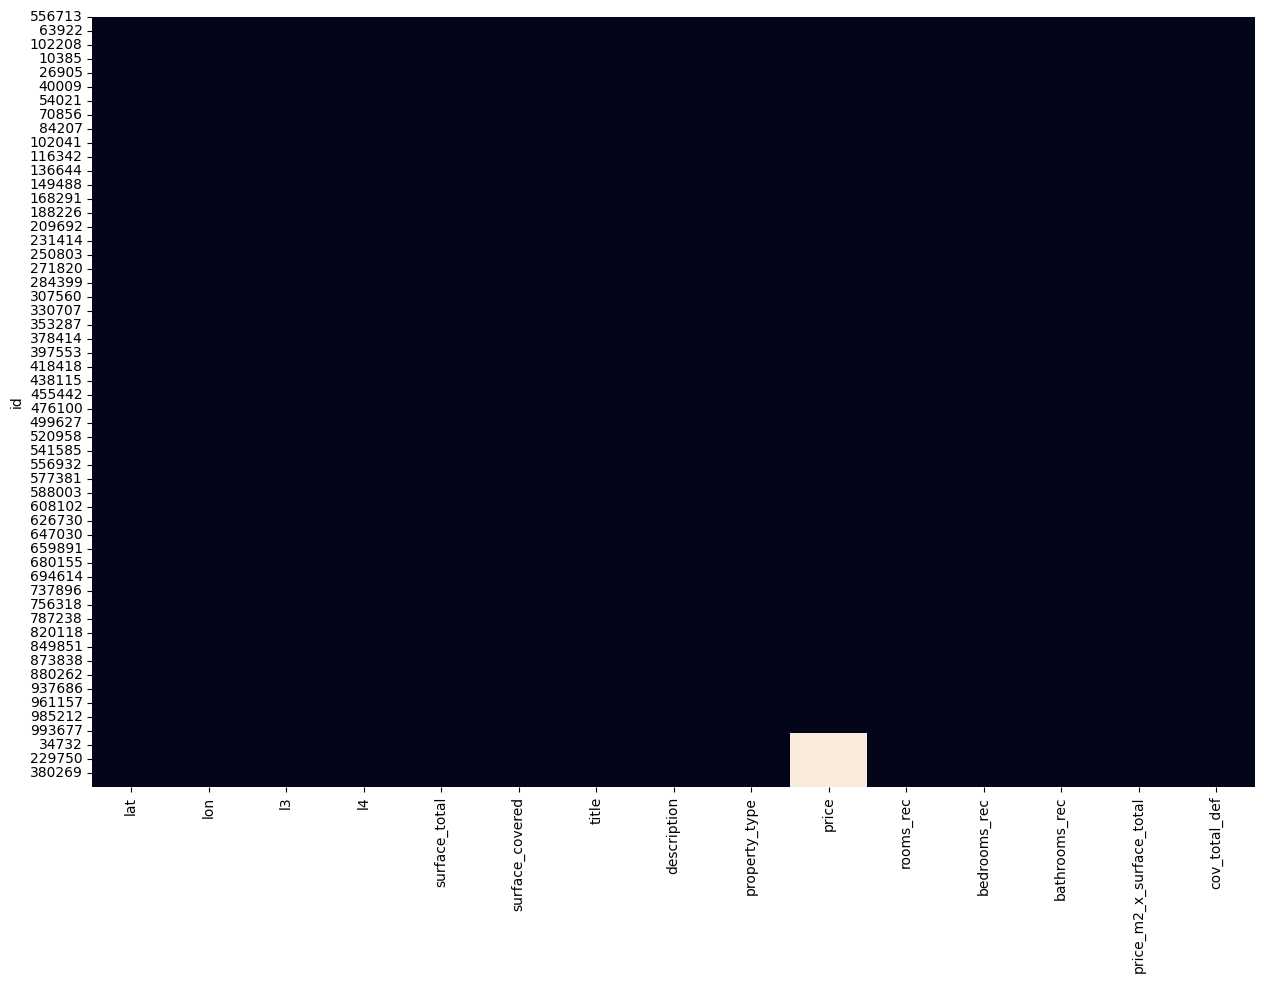

In [99]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(df.isnull(), cbar=False)

# Keywords

Agregamos mas atributos de palabras claves para que ayude al modelo.

In [100]:


df['PH'] = (
    df['title'].astype(str).str.lower().str.contains('ph', na=False) |
    df['description'].astype(str).str.lower().str.contains('ph', na=False)
).astype(int)

df['pileta'] = (
    df['title'].astype(str).str.lower().str.contains('pileta|piscina|natatorio', na=False) |
    df['description'].astype(str).str.lower().str.contains('pileta|piscina|natatorio', na=False)
).astype(int)



df['a_estrenar'] = (
    df['title'].astype(str).str.lower().str.contains('a estrenar|para estrenar|sin estrenar', na=False) |
    df['description'].astype(str).str.lower().str.contains('a estrenar|para estrenar|sin estrenar', na=False)
).astype(int)

df['de_pozo'] = (
    df['title'].astype(str).str.lower().str.contains('de pozo|pozo', na=False) |
    df['description'].astype(str).str.lower().str.contains('de pozo|pozo', na=False)
).astype(int)



In [101]:
f=df["l4"]=="Palermo Chico"
df.loc[f,"Palermo_Chico"]=1
df["Palermo_Chico"].fillna(0,inplace=True)

C:\Users\chris\AppData\Local\Temp\ipykernel_14480\1386453931.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Palermo_Chico"].fillna(0,inplace=True)


In [102]:
f=df["l4"]=="Palermo"
df.loc[f,"Palermo"]=1
df["Palermo"].fillna(0,inplace=True)

C:\Users\chris\AppData\Local\Temp\ipykernel_14480\1633183090.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Palermo"].fillna(0,inplace=True)


## 3. Entrenamiento del modelos (AA)

In [103]:
f_ent = df["price"].notna()
df_ent=df.loc[f_ent].copy()
df_ent.shape

(94011, 21)

In [104]:

df_ent = df_ent.select_dtypes(['number', 'bool'])
print(df_ent.columns)
X = df_ent[df_ent.columns.drop('price')]
y = df_ent['price']

Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'rooms_rec',
       'bedrooms_rec', 'bathrooms_rec', 'price_m2_x_surface_total',
       'cov_total_def', 'PH', 'pileta', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')


In [202]:
X = df_ent[df_ent.columns.drop('price')]
y = df_ent['price']

# Entrenamos el modelo con todos los datos de entrenamiento.csv, con los mejores hiperparámetros
n_estimators = 500
max_depth = 30
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=4, random_state=42)

reg.fit(X, y)


RandomForestRegressor(max_depth=30, n_estimators=500, n_jobs=4, random_state=42)

In [203]:
f_ap=df["price"].isna()
df_ap=df.loc[f_ap].copy()
df_ap.shape

(7012, 21)

In [204]:
# Hacemos en df_ap la misma limpieza que en df_ent
# df_ap = df_ap.fillna(0)

df_ap = df_ap.select_dtypes(['number', 'bool'])

X_ap = df_ap[X.columns]
y_ap = df_ap['price'] # no es necesario!

# Predecimos los precios del dataset a predecir
y_pred_ap = reg.predict(X_ap)
y_pred_ap

array([476745.64003891, 790000.        , 214816.39333333, ...,
       824495.10526316, 200595.16218475, 248913.84199682], shape=(7012,))

## 4. Solución para subir Kaggle

In [ ]:
# Lleno el precio de df_ap con las predicciones
df_ap["price"] = y_pred_ap

# Grabo el df_ap en un archivo csv para subir a Kaggle
df_ap["price"].to_csv("solucion_lombardo.csv")

In [206]:
# Importancia de las columnas
pd.DataFrame({"importance": reg.feature_importances_}, index=X.columns).sort_values(by="importance", ascending=False)

,importance
price_m2_x_surface_total,0.711461
lon,0.051389
surface_covered,0.049713
lat,0.039211
cov_total_def,0.035701
surface_total,0.031925
Palermo_Chico,0.018148
tiene_pileta,0.013539
bathrooms_rec,0.013123
rooms_rec,0.011465


<Axes: xlabel='importance', ylabel='None'>

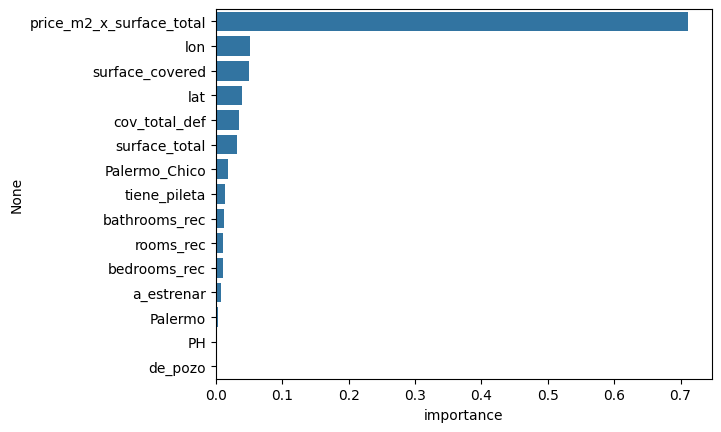

In [207]:
# Importancia de las columnas
importances = pd.DataFrame({"importance": reg.feature_importances_}, index=X.columns).sort_values(by="importance", ascending=False)
importances
sns.barplot(data=importances,x="importance",y=importances.index)